# Simple Model Building 

This script builds baseline classification models to predict illness based on
health indicators. The focus is on demonstrating the usability of the cleaned
and preprocessed dataset rather than achieving high accuracy.

In [14]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

In [11]:
# Load the preprocessed dataset (ready for modeling)
df = pd.read_csv("../Data/data_preprocessed.csv")
df.head()

,Exercise_Frequency,Blood_Pressure,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Family_History,Illness,...,minor_smoking_flag,minor_alcohol_flag,gender_Male,smoking_Unknown,smoking_Yes,Medication_Use_Regular,Alcohol_Consumption_Moderate,Alcohol_Consumption_Unknown,Cholesterol_Level_High,Cholesterol_Level_Normal
0,1,2,3,90,16.6,119,3.6,143.6,0,1,...,0,0,0,0,0,0,1,0,0,0
1,1,2,1,20,29.9,69,9.9,121.8,1,0,...,0,0,0,0,1,0,0,1,0,1
2,4,3,1,52,33.5,54,8.5,107.0,1,1,...,0,0,1,0,1,0,0,0,1,0
3,4,2,1,15,20.3,72,9.5,92.1,0,1,...,1,1,1,1,0,0,0,1,1,0
4,3,3,2,60,36.0,58,4.4,113.6,0,1,...,0,0,1,0,0,0,1,0,1,0


# Prepare Features and Target Variable

Split the dataset into:
- X (features): All columns except 'Illness'
- y (target): 'Illness' column (0 = No illness, 1 = Yes illness)

In [12]:
# Separate features and target
x = df.drop(['Illness'], axis=1)
y = df[['Illness']]

# RandomForest Model (Without Scaling)

Model 1: Random Forest Classifier
- Ensemble method using multiple decision trees
- Does NOT require feature scaling
- Built-in regularization parameters

In [13]:
# Split data into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,      # 20% for testing
    random_state=42      # For reproducible results
)

Train Score: 0.7975
Test Score: 0.455
accuracy_score: 0.455


<Axes: >

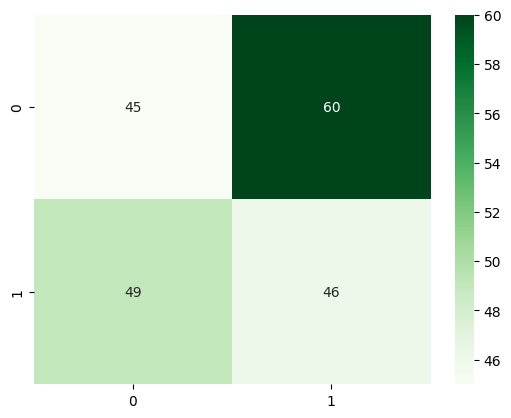

In [21]:
# Initialize Random Forest with regularization parameters
rf_regularized = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=10,  # Minimum samples required to split a node
    min_samples_leaf=5,    # Minimum samples required at a leaf node
    max_features='sqrt',   # Number of features to consider for best split
    random_state=42        # For reproducibility
)
# Train the model
rand_model = rf_regularized.fit(x_train, y_train)

# Evaluate on training data
print(f'Train Score: {rand_model.score(x_train, y_train)}')
# Evaluate on testing data
print(f'Test Score: {rand_model.score(x_test, y_test)}')

# Make predictions
rand_pred = rand_model.predict(x_test)

# Calculate accuracy
print(f'accuracy_score: {accuracy_score(y_test, rand_pred)}')
# Create and display confusion matrix
cm = confusion_matrix(y_test, rand_pred)
sns.heatmap(cm, annot=True, cmap='Greens')


# Random Forest Results Interpretation:
- Train Score: 0.79750 (79.75% accuracy on training data)
- Test Score: 0.45500 (45.5% accuracy on test data)
- Overfitting Gap: 34.25% (high overfitting)
- Model performs worse than random guessing on test data

# Logistic Regression Model (With Scaling)

Model 2: Logistic Regression
- Linear model for binary classification
- REQUIRES feature scaling for better performance
- Good baseline for comparison

In [17]:
# Apply StandardScaler for feature scaling
std = StandardScaler()
for col in x.columns:
    x[col] = std.fit_transform(x[[col]])

In [18]:
# Split scaled data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42
)

Train Score: 0.5725
Test Score: 0.465
accuracy_score: 0.465


<Axes: >

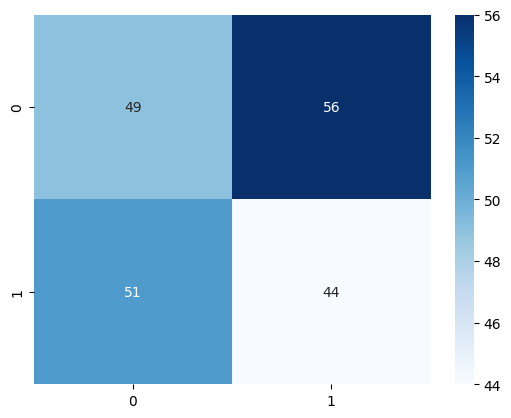

In [22]:
# Initialize and train Logistic Regression model
logi = LogisticRegression()
logi_model = logi.fit(xtrain, ytrain)

# Evaluate on training data
print(f'Train Score: {logi_model.score(xtrain, ytrain)}')
# Evaluate on testing data
print(f'Test Score: {logi_model.score(xtest, ytest)}')

# Make predictions
logi_pred = logi_model.predict(xtest)
# Calculate accuracy
print(f'accuracy_score: {accuracy_score(ytest, logi_pred)}')
# Create and display confusion matrix
cm = confusion_matrix(ytest, logi_pred)
sns.heatmap(cm, annot=True, cmap='Blues')

# Logistic Regression Results Interpretation:
- Train Score: 0.57250 (57.25% accuracy on training data)
- Test Score: 0.46500 (46.5% accuracy on test data)
- Overfitting Gap: 10.75% (less overfitting than Random Forest)
- Still performs slightly worse than random guessing

# Feature Correlation

Analyze correlation of all features with target variable 'Illness'
Helps understand which features are most predictive

In [23]:
# Calculate correlations with Illness
df.corr()['Illness'].sort_values(ascending=False)

Illness                         1.000000
alcohol_missing_flag            0.079675
Alcohol_Consumption_Unknown     0.069466
BMI                             0.046625
Heart_Rate                      0.039397
Family_History                  0.035385
Exercise_Frequency              0.027082
Cholesterol_Level_Normal        0.024243
gender_Male                     0.023014
Blood_Sugar_Level               0.021042
Blood_Pressure                  0.014320
Age                             0.012108
Sleep_Hours                     0.005211
smoking_Yes                    -0.009806
medication_missing_flag        -0.017043
minor_alcohol_flag             -0.017590
Stress_Level                   -0.028570
Cholesterol_Level_High         -0.029419
minor_smoking_flag             -0.032554
Medication_Use_Regular         -0.038495
smoking_Unknown                -0.041719
Alcohol_Consumption_Moderate   -0.062002
Name: Illness, dtype: float64

Key Reasons for Poor Correlation:

1. Data Limitations (only 1000 samples, 35% missing values)
2. Complex Healthcare Domain (basic features alone are insufficient)
3. Non-Linear Relationships (Pearson correlation cannot capture them)
4. Data Collection Issues (self-reporting bias)
5. Lack of Domain-Specific Features (insufficient medical/diagnostic variables)

# This is why the model performed worse!!!

1. Model Performance Comparison:
   - Random Forest overfits significantly (79.75% train vs 45.5% test)
   - Logistic Regression shows less overfitting but still poor test accuracy
   - Both models perform near or below random guessing (50%)

2. Feature Analysis:
   - No strong individual predictors for illness
   - Weakest correlations suggest complex relationships
   - Missing data flags (alcohol, medication) appear in top correlations

3. Dataset Quality Confirmation:
   ✓ No missing values
   ✓ All features properly scaled (for Logistic Regression)
   ✓ Target variable properly encoded
   ✓ Ready for advanced modeling techniques

4. Why Such Low Accuracy?
   - Illness prediction is inherently complex
   - Dataset may need more samples or features
   - Simple models insufficient for this problem
   - Non-linear relationships require advanced models

5. IMPORTANT NOTE:

   This project's PRIMARY FOCUS is DATA CLEANING AND PREPROCESSING.

   The models shown are SIMPLE BASELINES to demonstrate that:
   - The dataset is properly cleaned
   - All features are properly formatted
   - The data is ready for advanced modeling